Models can request to call tools that perform tasks such as fetching data from a database, searching the web, or running code

In [4]:
import groq
import langchain
import langchain_groq

print("groq:", groq.__version__)
print("langchain:", langchain.__version__)
print("langchain_groq:", langchain_groq.__version__)

groq: 0.37.1
langchain: 1.3.4
langchain_groq: 1.1.2


In [5]:
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model

load_dotenv()

model = init_chat_model("groq:qwen/qwen3-32b")

response = model.invoke("Why do parrots speak?")
print(response.content)

<think>
Okay, so I need to figure out why parrots can talk. Let me start by recalling what I know. Parrots are known for their ability to mimic human speech, but why do they do that? I think it might have to do with their natural behavior. Maybe they imitate sounds in their environment. But why would they evolve that ability?

First, I should consider their biology. Parrots have a syrinx, which is the vocal organ in birds. I remember that the syrinx allows them to produce a wide range of sounds. But how is that different from other birds? Maybe their syrinx has a more complex structure, allowing for more varied and precise sounds. That could be a factor in their ability to mimic human speech.

Then there's the aspect of social behavior. Parrots are highly social animals. In the wild, they live in flocks, so communication must be important. Maybe mimicking sounds is a way to integrate into the group or to signal to others. If they can imitate their flock members' calls, they can better 

In [6]:
import os
from langchain.chat_models import init_chat_model

os.environ['GROQ_API_KEY'] = os.getenv("GROQ_API_KEY")

model = init_chat_model("groq:qwen/qwen3-32b")
response = model.invoke("why do parrots speak?")
response.content

'<think>\nOkay, so I need to figure out why parrots can talk. Let me start by recalling what I know. Parrots are known for mimicking human speech, right? But why do they do that? Is it just an imitation, or is there a deeper reason?\n\nFirst, maybe their vocal organs are different from other birds. I remember something about their syrinx, which is the bird version of a voice box. How does that work? Maybe it allows them to produce a wider range of sounds. But why would they evolve that ability?\n\nAlso, parrots are social animals. They live in flocks, so maybe they use vocalizations to communicate with each other. If they can mimic human speech, perhaps it\'s an extension of their natural communication skills. Do they use similar mimicry in the wild? I think some parrots copy the calls of other birds or even other species. So maybe the ability to mimic is part of their social behavior.\n\nAnother angle: do parrots talk for attention? Like, when they\'re in captivity, they might mimic h

In [7]:
from langchain.tools import tool

@tool
def get_weather(location:str)->str:
    """Get the weather at a location"""
    respone = model.invoke(f"what is the current weather in {location}")
    return response.content


model_with_tool = model.bind_tools([get_weather])
 
response = model_with_tool.invoke("What is the weather in Tokyo?")
response.tool_calls

[{'name': 'get_weather',
  'args': {'location': 'Tokyo'},
  'id': 'st1yysa5a',
  'type': 'tool_call'}]

tool execution

In [8]:
#Step 1: Model generates tool calls
messages = [{'role':'user','content':'What is the weather in boston?'}]
ai_msg = model_with_tool.invoke(messages)
messages.append(ai_msg)

#Step 1: Execute tools and collect results
for tool_call in ai_msg.tool_calls:
    #execute tools with generated arguments
    tool_result = get_weather.invoke(tool_call)
    messages.append(tool_result)

#Step 3: Pass the result back to model for final response
final_response = model_with_tool.invoke(messages)
print(final_response.text)

The weather in Boston is currently 68°F with clear skies.


In [9]:
#Step 1: Model generates tool calls
messages = [{'role':'user','content':'who is salman khan?'}]
ai_msg = model_with_tool.invoke(messages)
messages.append(ai_msg)

#Step 1: Execute tools and collect results
for tool_call in ai_msg.tool_calls:
    #execute tools with generated arguments
    tool_result = get_weather.invoke(tool_call)
    messages.append(tool_result)

#Step 3: Pass the result back to model for final response
final_response = model_with_tool.invoke(messages)
print(final_response.text)

It seems like you might be disappointed that I couldn't provide information about Salman Khan. While I can't access biographical details, I’d be happy to help with other questions or topics. What would you like to discuss next? 😊


In [10]:
messages

[{'role': 'user', 'content': 'who is salman khan?'},
 AIMessage(content="I don't have access to biographical information about people, including Salman Khan. Would you like me to help with something else?", additional_kwargs={'reasoning_content': 'Okay, the user is asking "who is Salman Khan?" Let me think about the tools I have. The only tool provided is get_weather, which fetches weather based on location. Salman Khan is a person, not a location, so the get_weather function isn\'t relevant here. Since there\'s no function to retrieve information about people, I can\'t use any tool. I should inform the user that I don\'t have the right tool to answer their question. I need to check if there\'s another function, but the tools listed only include get_weather. So, I\'ll let them know I can\'t help with that.\n'}, response_metadata={'token_usage': {'completion_tokens': 157, 'prompt_tokens': 153, 'total_tokens': 310, 'completion_time': 0.331583978, 'completion_tokens_details': {'reasoning_

another way of making tool

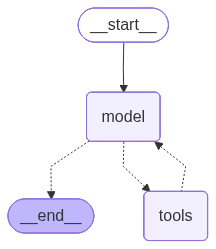

In [11]:
from langchain.agents import create_agent

def get_weather(city:str)->str:
    """get weather of the city"""
    return f"the weather in {city} is summer"

agent = create_agent(
    model = 'groq:qwen/qwen3-32b',
    tools = [get_weather],
    system_prompt="You are a helpful assistant"
)

agent

In [12]:
from langchain.agents import create_agent
import os

# Set your Groq API Key, ALREADY SET


def get_weather(city: str) -> str:
    """Get the current weather for a city."""

    weather_data = {
        "mumbai": "Temperature: 31°C, Condition: Partly Cloudy",
        "delhi": "Temperature: 38°C, Condition: Sunny",
        "bangalore": "Temperature: 26°C, Condition: Light Rain",
        "kolkata": "Temperature: 33°C, Condition: Humid",
        "chennai": "Temperature: 30°C, Condition: Moderate Rain"
    }

    return weather_data.get(
        city.lower(),
        f"Weather data for '{city}' is unavailable."
    )


agent = create_agent(
    model="groq:qwen/qwen3-32b",
    tools=[get_weather],
    system_prompt="""
You are a helpful AI assistant.

- Answer general knowledge questions using your own knowledge.
- Only use the weather tool when the user asks about weather.
- If a question does not require a tool, answer it directly.
"""
)

response = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Who is salman khan?"
            }
        ]
    }
)

print(response["messages"][-1].content)

Salman Khan is a renowned Indian actor, producer, and philanthropist. He is one of the highest-paid actors in the Indian film industry and has starred in numerous successful Bollywood movies such as *Dabangg*, *Bajrangi Bhaijaan*, and *Sultan*. He is also known for his work in television, including the popular show *Hum Log*, and for his contributions to charitable causes through the Salman Khan Foundation.
